# Phase 2: the structural encoding, explained from zero

**Read [`00-concepts.ipynb`](00-concepts.ipynb) and [`01-index-method.ipynb`](01-index-method.ipynb) first.**
Notebook 00 builds the machine: cycles, engines, latency, lockers, footprint.
Notebook 01 builds the index method: cubes, fields, covers and the joint query.
It ends on an uncomfortable measurement (§11.2): on the eight public programs the
joint optimiser accepts **not one improvement**, so every result is the bootstrap.

This notebook is about the first attempt to change that, called **Phase 2**. It
asks one question, stated by the author at the start of the plan:

> *Can an encoding of compilation choices expose reusable structure that direct
> index schemata can exploit?*

It explains the encoding in full, runs it by hand on a program small enough to
see completely, then runs it on real programs. It then shows where it failed,
what it gained against every baseline, and **why it did not gain more**. Those
reasons are the starting point of the two improvement rounds explained in
[`03-objective-index-search.ipynb`](03-objective-index-search.ipynb).

**Source of truth.** The Phase 2 code lives under `research/`, beside the accepted
compiler and never inside it. Every rule, figure and number below comes from
running those modules or from reading the frozen evidence under
`results/phase2_structural_encoding/`. Nothing is retyped. If a module changed,
these cells would disagree with the prose, and you would see it.

**How to run this.** Use the same kernel as notebooks 00 and 01 and run the cells
in order, top to bottom. Nothing here writes to the repository. Two cells run a
search against the clock. Their exact counts can differ slightly on another
machine, and the prose says where.

---

## 0. Setup

Five research modules matter, and each owns exactly one thing. `structural_encoding`
is the codec: what a bit string means. `structural_oracle` enumerates every legal
compilation by brute force, and it deliberately never imports the codec, so the
two can check each other. `structural_search` owns the search and its bounds,
`structural_models` owns covers and proposals, and `run_structural_experiments`
turns real programs into search domains.

In [1]:
import collections
import json
import math
import sys
from pathlib import Path

ROOT = Path("/Users/alberto/Documents/projects/CausalBool/luminal-challenge").resolve()
for entry in (str(ROOT / ".reference"), str(ROOT), str(ROOT / "notebooks")):
    if entry not in sys.path:
        sys.path.insert(0, entry)

import machine                       # the frozen machine model and validator
import direct_contract as dc         # derived program facts, lifetimes, footprint
import direct_compiler as dcomp      # the accepted direct-index compiler (bootstrap + optimiser)
import direct_optimizer as dopt      # its target rectangles and windows
import schema_index as si            # cubes and fields

from research import structural_encoding as se        # THE codec of Phase 2
from research import structural_oracle as so          # brute-force enumeration, independent of the codec
from research import structural_search as ss          # depth-first search with admissible bounds
from research import structural_models as sm          # exact covers, serialisation, proposals
from research import run_structural_experiments as rse  # real-program domains, the controller, the samplers

import viz                           # every figure, in notebooks 00 to 03

EVIDENCE = ROOT / "results/phase2_structural_encoding"
FIXTURES = {f["id"]: f for f in json.loads((ROOT / "plan/phase2/FIXTURES.json").read_text())["fixtures"]}

for name, module in (("structural_encoding", se), ("structural_oracle", so),
                     ("structural_search", ss), ("structural_models", sm),
                     ("run_structural_experiments", rse), ("viz", viz)):
    print(f"{name:28} {Path(module.__file__).relative_to(ROOT)}")
print(f"\n{len(FIXTURES)} frozen tiny fixtures:", ", ".join(FIXTURES))

structural_encoding          research/structural_encoding.py
structural_oracle            research/structural_oracle.py
structural_search            research/structural_search.py
structural_models            research/structural_models.py
run_structural_experiments   research/run_structural_experiments.py
viz                          notebooks/viz.py

12 frozen tiny fixtures: chain_0, chain_1, many_ready_0, many_ready_1, memory_bottleneck_0, memory_bottleneck_1, sparse_0, sparse_1, mixed_lifetimes_0, mixed_lifetimes_1, unused_and_shared_0, unused_and_shared_1


---

# 1. Why a second phase, and what it promised

Notebook 01 wrote every decision as a **physical number**: an issue cycle is the
cycle itself, an address is the locker number. A joint query over four operations
then carries four cycles and four addresses in one index, and most of the integers
in that index denote illegal compilations: an operation issued before its input
exists, two values in the same locker at once. The query has to build covers that
exclude all of them before it can find the few legal ones. Notebook 01 §10 showed
the cost. One query visits tens of thousands of cubes, and under the default
budget many queries end `UNKNOWN`.

Phase 2 proposes to **change the coordinates**. Store each decision not as *which
cycle* but as *which of the choices still legal at this point*. The first field
says "the 0th legal option", the next field is read against whatever the first
choice left open, and so on. Legality is then enforced by the way a code is read,
rather than by predicates that the search must intersect.

The plan separates what this could achieve into four hypotheses, and insists that
success at one level does not establish the next:

| | question | what would count as evidence |
|---|---|---|
| **H1** | Is the encoding sound, canonical and complete on its declared domain? | proofs, plus exact agreement with an independent brute-force enumeration |
| **H2** | Does it make the search cheaper or better on matched problems? | equal domains, equal budgets, construction time included |
| **H3** | Are *good* compilations more compact in these coordinates than random ones? | exact covers of the good set, against size-matched random controls |
| **H4** | Can a model built from good examples find unseen good compilations? | held-out outcomes against matched search without the model |

Keep the four apart while reading. A correct codec (H1) can be useless for search
(H2). A compact good set (H3) can still teach a model nothing new (H4). The
verdicts at the end are H1 supported, H2 supported, H3 supported only as a triage
signal, and H4 inconclusive.

---

# 2. Warm-up: a compilation is a short list of choices

Phase 2 was built and verified on **twelve tiny frozen fixtures** before anything
touched a real program. Each is a small program in which almost everything is
already fixed, leaving two issue times and two addresses free. That is small enough
to list every legal answer, which is the point: nothing below needs to be taken on
trust.

We use `chain_0` throughout. Here it is, in full.

In [2]:
record = FIXTURES["chain_0"]
domain = se.Domain.from_record(record)
facts = domain.facts
program = record["program"]

print(f"{'id':>3}  {'op':6} {'engine':7} {'reads':8} {'writes':7} latency")
for op in program["operations"]:
    i = op["id"]
    reads = ",".join(op.get("args", [])) or "-"
    print(f"{i:>3}  {op['op']:6} {facts.engine[i]:7} {reads:8} {op.get('dest') or '-':7} {facts.latency[i]}")
print()
print("fixed issue times :", record["fixed_times"])
print("fixed addresses   :", record["fixed_addresses"])
print("free issue times  :", record["time_domains"])
print("free addresses    :", record["address_domains"])

 id  op     engine  reads    writes  latency
  0  load   load    -        a       3
  1  add    scalar  a,a      b       1
  2  mul    scalar  b,b      c       2
  3  sub    scalar  c,b      d       1
  4  store  store   d        -       1

fixed issue times : {'2': 4, '3': 6, '4': 7}
fixed addresses   : {'c': 1, 'd': 0}
free issue times  : {'0': [0, 1], '1': [2, 3, 4]}
free addresses    : {'a': [0, 1, 2], 'b': [0, 1, 2]}


Five operations: load `a`, add it to itself to get `b`, square `b` to get `c`,
subtract to get `d`, store `d`. Operations 2, 3 and 4 already have fixed issue
cycles (4, 6, 7), and `c` and `d` already have lockers (1 and 0). **Four things
are still open**:

- `t0`, the issue cycle of the load, is 0 or 1;
- `t1`, the issue cycle of the add, is 2, 3 or 4;
- `a`, the locker of `a`, is 0, 1 or 2;
- `b`, the locker of `b`, is 0, 1 or 2.

That is 2 × 3 × 3 × 3 = **54** combinations. Here is the one the compiler starts
from, the **incumbent**.

incumbent times    : {0: 0, 1: 3, 2: 4, 3: 6, 4: 7}
incumbent addresses: {'a': 0, 'b': 0, 'c': 1, 'd': 0}
C = 8 cycles, S = 2 words, J = C x S = 16


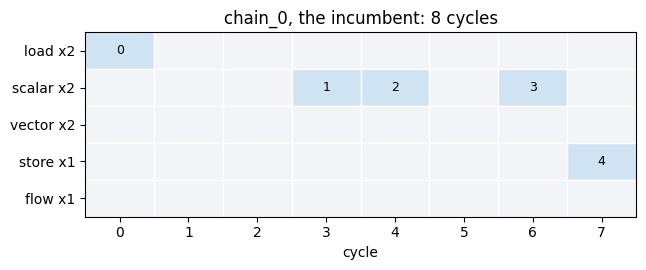

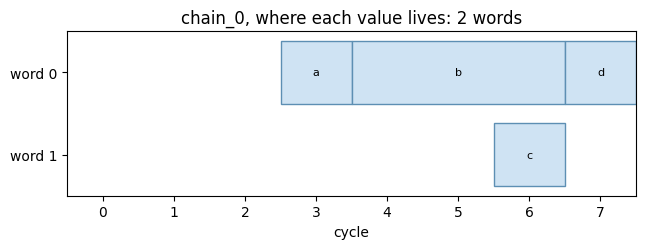

In [3]:
inc_times, inc_addresses = domain.incumbent_times, domain.incumbent_addresses
C0, S0, J0 = se.objective(facts, inc_times, inc_addresses)
print("incumbent times    :", dict(sorted(inc_times.items())))
print("incumbent addresses:", inc_addresses)
print(f"C = {C0} cycles, S = {S0} words, J = C x S = {J0}")

viz.show_timeline(dc.compilation(facts, inc_times, inc_addresses)["bundles"],
                  f"chain_0, the incumbent: {C0} cycles")
viz.show_lifetimes(facts, inc_addresses, dc.lifetimes(facts, inc_times), C0,
                   f"chain_0, where each value lives: {S0} words")

**J = C × S is the quantity every Phase 2 search minimises.** It is not the official
score: that is a geometric mean of the cycle and memory ratios against the serial
baseline, computed over the whole suite (notebook 00 §10). J is a per-program
stand-in that rewards lowering either factor. Both are reported later, and they do
not always agree.

How many of the 54 combinations are legal? The **oracle** answers by brute force.
It builds every combination, hands each to the pinned validator and runs the test
cases. It shares no code with the codec, so if the two ever disagree, one of them
is wrong.

In [4]:
oracle = so.enumerate_feasible(record, 65536)
print(f"combinations tried : {oracle['cartesian_assignments']}")
print(f"legal compilations : {oracle['feasible_count']}\n")
print(f"{'t0':>3} {'t1':>3}  {'a':>2} {'b':>2}    C  S   J")
for x in sorted(oracle["feasible"], key=lambda x: (x["product"], x["addresses"]["a"])):
    t, a = x["times"], x["addresses"]
    print(f"{t['0']:>3} {t['1']:>3}  {a['a']:>2} {a['b']:>2}    {x['cycles']}  {x['scratch']}  {x['product']}")

combinations tried : 54
legal compilations : 6

 t0  t1   a  b    C  S   J
  0   3   0  0    8  2  16
  0   3   1  0    8  2  16
  0   3   0  2    8  3  24
  0   3   1  2    8  3  24
  0   3   2  0    8  3  24
  0   3   2  2    8  3  24


**Six legal out of fifty-four.** Every one has `t0 = 0` and `t1 = 3`. The only
freedom left is where `a` and `b` live. Two of the six reach J = 16 and the other
four pay one extra word.

Keep the ratio in mind: 6 out of 54 is 11%. In a real program the same ratio is
astronomically smaller, and that is the whole difficulty. The rest of this notebook
is about writing the 54, or rather the 6, down so that a search wastes less time
on the other 48.

---

# 3. Three ways to write the same four choices as bits

A search over an index needs every decision written as a **field**: a run of bits
at a fixed position (notebook 01 §4). The question is what the bits in a field
*mean*. Phase 2 compares four codecs, of which three matter here.

**Absolute.** The field holds the physical value. A cycle needs enough bits for any
cycle up to the program's horizon, and an address needs 8 bits for 256 lockers.
This is what notebook 01's joint query does.

**Static rank.** The field holds the *position* of the value in the declared list
for that decision. `t1` is one of three declared values, so its field needs only
two bits.

**Structural rank.** The field *also* holds a position, but in the list of options
**still legal given every decision read so far**. The width is the same as the
static rank, because it must fit the worst case. What changes is the meaning of
each field, which now depends on the fields decoded before it.

The fourth codec, `vector_block`, writes vector addresses in units of eight words.
It matters only for vector programs and is not needed to follow the argument.

The widths come from one rule: a field that must be able to name one of M options
reserves ⌈log₂ M⌉ bits.

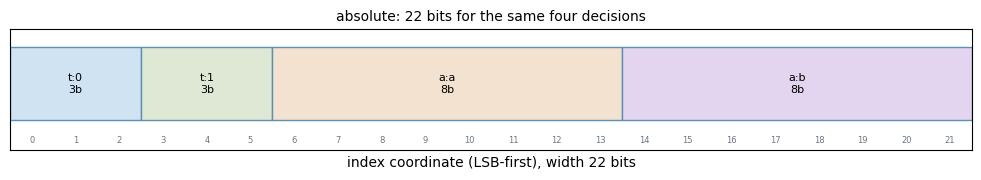

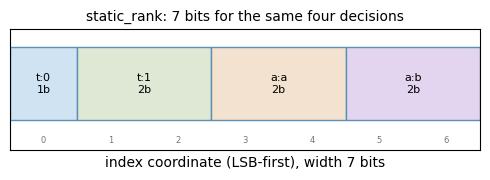

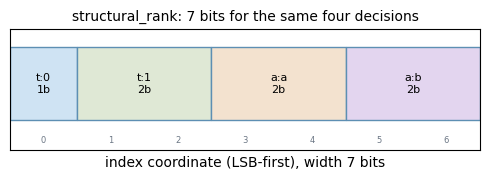

In [5]:
for codec in ("absolute", "static_rank", "structural_rank"):
    plan = se.layout(domain, codec)
    fields = [si.Field(f"{spec.key[0][0]}:{spec.key[1]}", spec.offset, spec.width)
              for spec in plan.fields]
    viz.show_index_layout(fields, plan.width, f"{codec}: {plan.width} bits for the same four decisions")

Twenty-two bits against seven. The absolute code has 2²² = **4,194,304** integers
to describe the same six legal compilations. The rank codes have 2⁷ = **128**.

The two rank codecs share one more detail, which is easy to miss and is essential
later. The declared lists are not stored in ascending order. **The incumbent's value
comes first**:

In [6]:
for key in domain.decision_keys():
    incumbent_value = inc_times[key[1]] if key[0] == "time" else inc_addresses[key[1]]
    print(f"{key[0]:8} {str(key[1]):3} declared {tuple(sorted(domain.ordered_domain(key)))}"
          f"   stored order {domain.ordered_domain(key)}   incumbent {incumbent_value}")

time     0   declared (0, 1)   stored order (0, 1)   incumbent 0
time     1   declared (2, 3, 4)   stored order (3, 2, 4)   incumbent 3
address  a   declared (0, 1, 2)   stored order (0, 1, 2)   incumbent 0
address  b   declared (0, 1, 2)   stored order (0, 1, 2)   incumbent 0


`t1` is declared as {2, 3, 4} but stored as (3, 2, 4), because the incumbent issues
the add at cycle 3. The same happens for every field. The consequence is the
**origin property**: the all-zero code means "take the incumbent's choice
everywhere", so code 0 decodes to the incumbent. A code with a few non-zero fields
is then a compilation that differs from the incumbent in a few decisions. The search
in §7 exploits this, and the improvement rounds in notebook 03 exploit it more.

---

# 4. Decoding one index by hand

Take the code **8**. In seven LSB-first bits it is `0001000`: bit 3 is set and
every other bit is clear. Bit 3 is the lowest bit of the `a` field. Decoding
reads the fields in decision order. At each field it builds the list of options
that are legal **now**, given what has been fixed so far, and uses the field's
value as a position in that list.

The cell below replays the decode step by step through the codec's own public
`options` function. It is the same list the decoder, the search and the tests
all use.

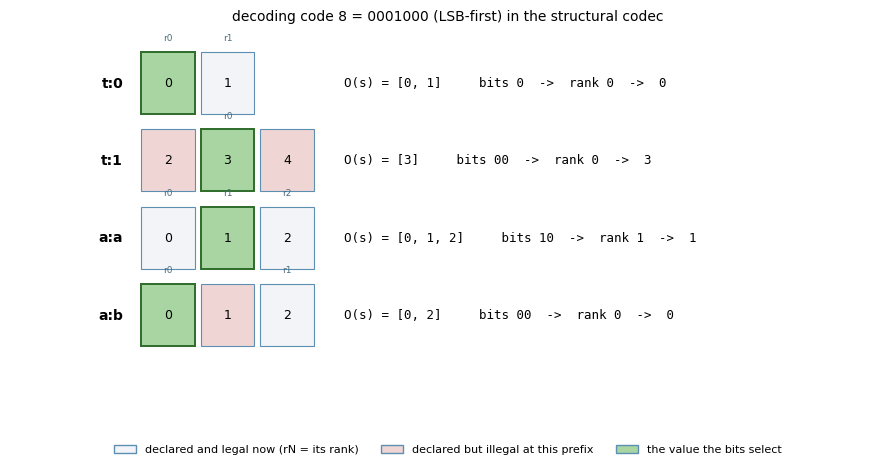

status  : COMPLETE
times   : {0: 0, 1: 3, 2: 4, 3: 6, 4: 7}
lockers : {'c': 1, 'd': 0, 'a': 1, 'b': 0}
C = 8, S = 2, J = 16


In [7]:
def replay_steps(domain, code, codec="structural_rank"):
    # Rebuild each decision's option list from the codec's own `options`,
    # following the decoder's recorded path. Returns one row per decision.
    result = se.decode(domain, code, codec)
    state = se.State(domain)
    rows = []
    for decision in result.decisions:
        key = (decision["kind"], decision["key"])
        if key[0] == "address" and state.lifetimes is None:
            state.recompute_lifetimes()
        legal = se.options(domain, state, key)
        bits = "".join(str((code >> (decision["offset"] + i)) & 1) for i in range(decision["width"]))
        row = {"label": f"{key[0][0]}:{key[1]}",
               "declared": sorted(domain.ordered_domain(key)),
               "options": legal, "bits": bits or "(none)", "rank": decision["field_value"],
               "chosen": decision["chosen"]}
        if decision["chosen"] is None:
            row["verdict"] = "DEAD_END" if not legal else f"rank {decision['field_value']} >= {len(legal)}: INVALID_CODE"
        rows.append(row)
        if decision["chosen"] is not None:
            (state.times if key[0] == "time" else state.addresses)[key[1]] = decision["chosen"]
    return result, rows


result, steps = replay_steps(domain, 8)
viz.show_decode_steps(steps, "decoding code 8 = 0001000 (LSB-first) in the structural codec")
print("status  :", result.status)
print("times   :", dict(sorted(result.times.items())))
print("lockers :", result.addresses)
print(f"C = {result.cycles}, S = {result.scratch}, J = {result.product}")

Read the four rows from top to bottom. Each one is a single decision.

**`t:0`, the load.** Both declared cycles are legal because nothing has been decided
yet. The field is one bit, `0`, so it takes rank 0: cycle 0, the incumbent's choice.

**`t:1`, the add.** Three cycles are declared, and **only one survives**. The add
reads `a`, and a load takes 3 cycles, so `a` exists from cycle 0 + 3 = 3. The add
cannot issue before cycle 3. Operation 2 is fixed at cycle 4 and reads `b`, and the
add takes 1 cycle, so the add must issue by cycle 4 − 1 = 3. The option list is
exactly `[3]`. The field's two bits `00` pick rank 0, and there was no alternative.

**`a:a`, the locker of `a`.** All three lockers are free while `a` is alive (cycle
3 only), so the list is `[0, 1, 2]`, with the incumbent's 0 first. The bits `10`
are LSB-first, so the value is 1: rank 1, **locker 1**. This is the only field where
code 8 departs from the incumbent.

**`a:b`, the locker of `b`.** `b` lives from cycle 4 to cycle 6. Locker 1 is taken
by `c`, which is fixed there and alive at cycle 6. So the list is `[0, 2]`. The
bits `00` pick locker 0.

The result is a legal compilation with J = 16. It is not *checked* to be legal
somewhere downstream. It is legal because at every step the decoder could only
choose among legal options. It is validated anyway:

In [8]:
cycles = machine.check_compilation(program, result.compilation)
for case in program["cases"]:
    machine.check_case(program, result.compilation, case)
print(f"pinned validator: {cycles} cycles, {len(program['cases'])} case(s) reproduce the reference output")

pinned validator: 8 cycles, 1 case(s) reproduce the reference output


## 4.1 Two codes that do not decode

Not every code names a compilation, and the codec says so instead of hiding it.
Here are codes 1 and 2.

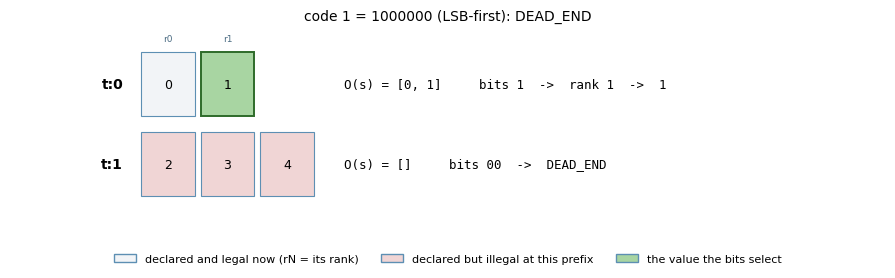

code 1: DEAD_END -- ('time', 1): no legal option remains



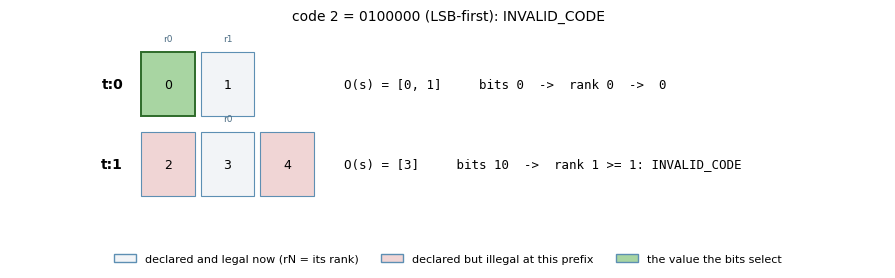

code 2: INVALID_CODE -- ('time', 1): rank 1 is past 1 options



In [9]:
for bad in (1, 2):
    result_bad, steps_bad = replay_steps(domain, bad)
    viz.show_decode_steps(steps_bad, f"code {bad} = {format(bad, '07b')[::-1]} (LSB-first): {result_bad.status}")
    print(f"code {bad}: {result_bad.status} -- {result_bad.reason}\n")

**Code 1 is a `DEAD_END`.** Its first bit picks rank 1, so the load issues at cycle 1.
That is a legal choice on its own. But then `a` exists only from cycle 4, while
the add must issue by cycle 3. The add has **no legal cycle at all**: every
declared value is red. The prefix is legal and cannot be completed. This is a
genuine property of the problem. No encoding can make the load at cycle 1 work.

**Code 2 is an `INVALID_CODE`.** The load is fine at cycle 0, and the add's list
is `[3]`, with one option. But the field's bits `10` ask for rank 1, and there is
no rank 1. The code points past the end of the list. This is a property of the
**code**, not of the problem: two bits can name four ranks and only one exists here.

The two failures mean different things, and they are counted separately everywhere
in Phase 2. A decoded compilation that the validator rejected would be a third
kind, a defect in the codec. It raises an error rather than being filed as a
dead end. None was ever observed.

---

# 5. The whole universe at once

Seven bits give 128 codes. Decode every one of them, with the static and the
structural codec, and colour each by the decoder's answer.

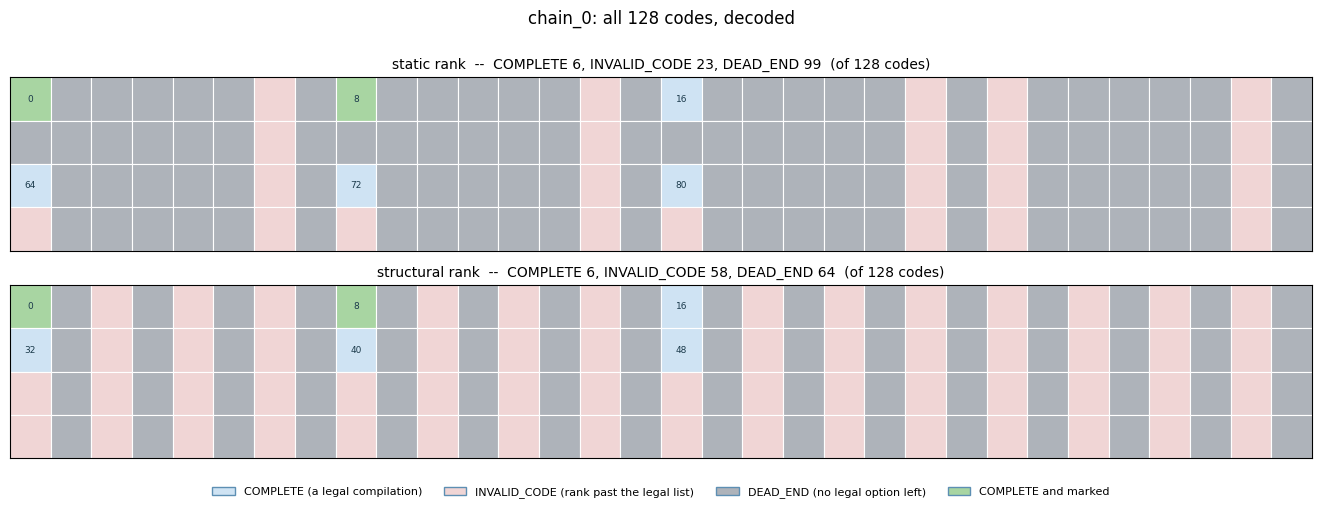

In [10]:
def statuses(domain, codec):
    width = se.layout(domain, codec).width
    return [se.decode(domain, z, codec).status for z in range(1 << width)]

chain_static = statuses(domain, "static_rank")
chain_structural = statuses(domain, "structural_rank")
viz.show_code_statuses(
    [("static rank", chain_static), ("structural rank", chain_structural)],
    "chain_0: all 128 codes, decoded", marked=[0, 8])

Both panels contain the same six legal compilations (blue and green; green marks
the two with J = 16). Codes 0 and 8 are the two best, and code 0 is the incumbent,
as the origin property promised. What differs is **how the other 122 codes fail**.

- Under the **static** rank, a field names a *declared* value whether or not it is
  legal. Illegal choices are therefore not seen when they are made. They surface
  later, when some following decision finds nothing left, so most failures are
  dead ends.
- Under the **structural** rank, an illegal choice cannot be named at all. It shows
  up at once as a rank past the end of a short list, an `INVALID_CODE`, at the field
  that made it. The 64 dead ends that remain are exactly the codes whose first bit
  puts the load at cycle 1. That is the genuine dead end of §4.1, and no encoding
  can remove it.

Now repeat it on all twelve fixtures.

In [11]:
print(f"{'fixture':22} {'bits':>4} {'legal':>6}   {'static: invalid / dead':>23}   {'structural: invalid / dead':>27}")
for fixture_id, fixture in FIXTURES.items():
    fixture_domain = se.Domain.from_record(fixture)
    counts = {codec: collections.Counter(statuses(fixture_domain, codec))
              for codec in ("static_rank", "structural_rank")}
    bits = se.layout(fixture_domain, "structural_rank").width
    s, r = counts["static_rank"], counts["structural_rank"]
    assert s["COMPLETE"] == r["COMPLETE"]
    print(f"{fixture_id:22} {bits:>4} {r['COMPLETE']:>6}   {s['INVALID_CODE']:>11} / {s['DEAD_END']:<9}"
          f"   {r['INVALID_CODE']:>13} / {r['DEAD_END']:<9}")

fixture                bits  legal    static: invalid / dead    structural: invalid / dead
chain_0                   7      6            23 / 99                     58 / 64       
chain_1                   9      6           198 / 308                   378 / 128      


many_ready_0              6      2             6 / 56                     58 / 4        


many_ready_1             10     40           559 / 425                   984 / 0        
memory_bottleneck_0       6     12            14 / 38                     52 / 0        
memory_bottleneck_1       9     18           110 / 384                   494 / 0        
sparse_0                  6     12            14 / 38                     52 / 0        


sparse_1                  9      9           199 / 304                   503 / 0        
mixed_lifetimes_0         6      6             6 / 52                     58 / 0        
mixed_lifetimes_1         9     18           162 / 332                   494 / 0        
unused_and_shared_0       6      6            12 / 46                     58 / 0        
unused_and_shared_1       9      6            54 / 452                   506 / 0        


Two facts to take from the table.

1. **The legal count is identical under both codecs on every fixture.** The
   encoding changes the coordinates, not the set of compilations. An improvement
   that exists in one exists in the other.
2. **The structural codec turns late failures into early ones.** On nine of the
   twelve fixtures it has *no* dead ends at all. The three that keep some
   (`chain_0`, `chain_1`, `many_ready_0`) are the ones where an early legal choice
   forecloses a later decision, as the load at cycle 1 does above. That is its whole mechanical
   advantage. A search reading structural fields discovers a bad choice at the
   field that made it and backs up at once, instead of carrying the bad choice
   down and failing several decisions later.

## 5.1 Why not simply make every code legal?

Six is not a power of two, so a 7-bit code must contain codes that are not
compilations. There are two tempting fixes, and the plan forbids both. The first
is to wrap an out-of-range rank around (`rank mod |options|`). The second is to pad
the list with repeats. Either would make every code decode, but then two codes
would name the same compilation. Encoding would stop being a function, and a
uniform draw of bits would favour whichever options were repeated. The codec is
therefore **partial on purpose**. Invalid codes are counted, never hidden. §9 shows
what that honesty costs when the program is real.

---

# 6. Is it correct? The proof obligations, run

The plan lists what the codec must satisfy before any experiment may use it. In
words:

| obligation | meaning |
|---|---|
| **soundness** | every code that decodes gives a compilation the validator accepts |
| **completeness** | every legal compilation of the declared domain has a code |
| **round trip** | encoding a legal compilation and decoding the code returns it |
| **injectivity** | two different codes never decode to the same compilation |
| **origin** | code 0 decodes to the incumbent |

Each has a short written argument in `PROOFS.md` of the accepted run. For
completeness the argument is: follow any legal compilation in decision order; each
next choice is legal against what came before, so it is in the option list; its
position in that list is its field. On the tiny fixtures the obligations can also
be **checked exhaustively** against the oracle. That check runs here, for every
fixture and both rank codecs.

In [12]:
checked = 0
for fixture_id, fixture in FIXTURES.items():
    fixture_domain = se.Domain.from_record(fixture)
    fixture_facts = fixture_domain.facts
    truth = {x["identity"] for x in so.enumerate_feasible(fixture, 65536)["feasible"]}
    for codec in ("static_rank", "structural_rank"):
        width = se.layout(fixture_domain, codec).width
        decoded = {}
        for z in range(1 << width):
            r = se.decode(fixture_domain, z, codec)
            if r.status != "COMPLETE":
                continue
            identity = se.canonical_json(se.normalise_compilation(fixture_facts, r.compilation))
            assert identity not in decoded, "injectivity"            # two codes, one compilation
            decoded[identity] = z
            assert se.encode(fixture_domain, r.compilation, codec) == z, "round trip"
        assert set(decoded) == truth, "soundness and completeness against the oracle"
        origin = se.decode(fixture_domain, 0, codec)
        assert origin.status == "COMPLETE" and origin.product == se.objective(
            fixture_facts, fixture_domain.incumbent_times, fixture_domain.incumbent_addresses)[2]
        checked += 1
print(f"all obligations hold on {checked} (fixture, codec) pairs: "
      f"{len(FIXTURES)} fixtures x 2 rank codecs, every code of every universe decoded")

all obligations hold on 24 (fixture, codec) pairs: 12 fixtures x 2 rank codecs, every code of every universe decoded


If any assertion failed, this cell would stop with the name of the broken
obligation. The accepted campaign ran the same comparison on all four codecs: 24
exhausted codec/oracle comparisons, 0 round-trip failures and 0 defects. This is
the evidence behind **H1: supported**, scoped to the implemented domains.

A finite check does not prove the codec correct on every program. It supports a
written argument, and it would catch an implementation that broke one. §9 adds
the real-program evidence: 819 decoded public compilations validated with zero
discrepancies.

---

# 7. Searching in the new coordinates

A codec is only a way of reading bits. The **search** decides which codes to read.
Phase 2's search is the simplest exact one: walk the tree of decisions **depth-first**,
trying ranks in ascending order (incumbent first). Every time a complete legal
compilation appears, keep it if its J is **strictly** lower than the best so far.

`chain_0` cannot be improved, because its incumbent already has the lowest J. We
switch to `many_ready_1`, where it can: six constants are loaded and stored,
operations 4 and 5 are free, and the incumbent has J = 28.

In [13]:
record_mr = FIXTURES["many_ready_1"]
domain_mr = se.Domain.from_record(record_mr)
facts_mr = domain_mr.facts
plan_mr = se.layout(domain_mr, "structural_rank")
print("free decisions:", [f"{k[0]}:{k[1]}" for k in domain_mr.decision_keys()])
print("declared      :", [tuple(sorted(domain_mr.ordered_domain(k))) for k in domain_mr.decision_keys()])
print("bits          :", plan_mr.width, " codes:", 1 << plan_mr.width)
print("incumbent J   :", se.objective(facts_mr, domain_mr.incumbent_times, domain_mr.incumbent_addresses))
print("engine slots  :", machine.ENGINE_LIMITS["load"], "load,", machine.ENGINE_LIMITS["store"], "store per cycle")

free decisions: ['time:4', 'time:5', 'address:c4', 'address:c5']
declared      : [(0, 1, 2, 3, 4), (0, 1, 2, 3, 4), (0, 1, 2), (0, 1, 2, 3)]
bits          : 10  codes: 1024
incumbent J   : (7, 4, 28)
engine slots  : 2 load, 1 store per cycle


Every legal compilation is a path from the root of a tree to a leaf: pick `t4`,
then `t5`, then the locker of `c4`, then the locker of `c5`. Decoding every one of
the 1,024 codes and keeping the complete ones gives the whole tree. It is drawn
below as an **icicle**. Each band is one decision, each box is a choice, and a
box is as wide as the number of legal compilations below it. The bottom row is the
leaves, with their J.

Under each box is the search's **lower bound** for everything below it:
L_C × L_S. It is computed by the search's own functions, `cycle_bound` and
`scratch_bound`.

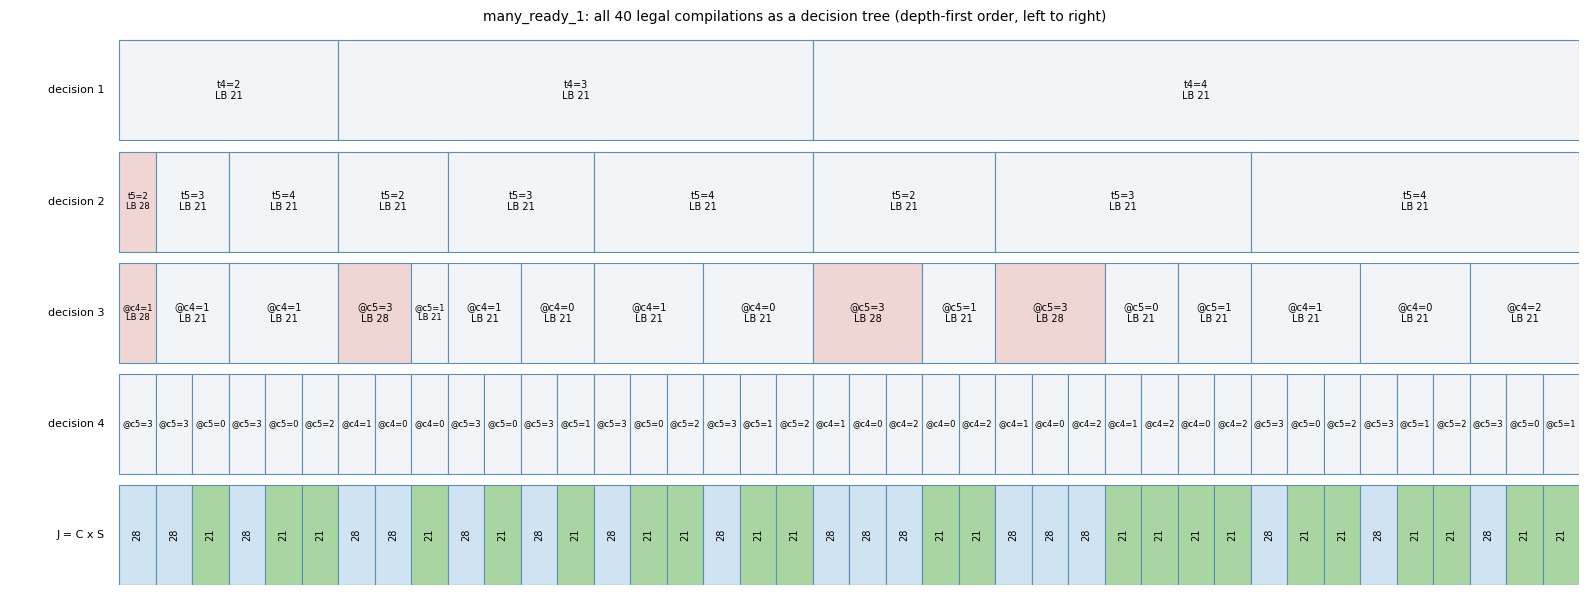

In [14]:
paths = []
for z in range(1 << plan_mr.width):
    r = se.decode(domain_mr, z, "structural_rank")
    if r.status == "COMPLETE":
        ranks = tuple(d["field_value"] for d in r.decisions)
        labels = tuple(("t" if d["kind"] == "time" else "@") + f"{d['key']}={d['chosen']}"
                       for d in r.decisions)
        paths.append((ranks, labels, r.product, r))
paths.sort()                                # rank order = the order depth-first search visits

notes, pruned_at_28 = {}, set()
for ranks, labels, product, r in paths:
    keys = [(d["kind"], d["key"]) for d in r.decisions]
    for depth in range(1, len(labels)):
        times = dict(domain_mr.fixed_times)
        addresses = dict(domain_mr.fixed_addresses)
        for (kind, which), d in zip(keys[:depth], r.decisions[:depth]):
            (times if kind == "time" else addresses)[which] = d["chosen"]
        schedule_done = all(k[0] != "time" for k in keys[depth:])
        live = ss.peak_live_width(facts_mr, dc.lifetimes(facts_mr, times)) if schedule_done else None
        bound = ss.cycle_bound(facts_mr, times) * ss.scratch_bound(facts_mr, addresses, live)
        notes[labels[:depth]] = f"LB {bound}"
        if bound >= 28:
            pruned_at_28.add(labels[:depth])

viz.show_decision_icicle(
    [(labels, product) for _, labels, product, _ in paths],
    f"many_ready_1: all {len(paths)} legal compilations as a decision tree (depth-first order, left to right)",
    depth_labels=["decision 1", "decision 2", "decision 3", "decision 4"],
    notes=notes, excluded=pruned_at_28, best=21)

A box reads `t4=3` for "operation 4 issues at cycle 3" and `@c5=0` for "`c5` goes
in locker 0". Notice that the third band does not always hold `c4`: under some
schedules it holds `c5`. The **allocation order depends on the decoded schedule**
(values are placed in order of when they are written), while each field keeps its
fixed bit position. The plan insists on exactly this: traversal order may depend on
the schedule, field offsets never do.

Forty leaves: 18 with J = 28 (blue) and 22 with J = 21 (green). Every J = 21 leaf
uses 3 words instead of 4. The red boxes are prefixes whose lower bound is already
28, so nothing below them can beat the incumbent.

**Where the bound comes from.** For any completion of a prefix:

- **L_C.** C is at least the program's dependency and engine bound, and at least
  one more than the latest cycle already placed.
- **L_S.** S is at least the end of the highest block already placed. Once the whole
  schedule is fixed, it is also at least the peak total width of values alive in the
  same cycle, because those need disjoint lockers.

Both factors are positive, so C × S ≥ L_C × L_S for **every** completion below the
prefix. If that product is already at least the best J found, the whole subtree can
be skipped without losing an improvement. This is what **admissible** means. The
bound may be loose, but it never cuts off something better. The accepted run
checked every bound against every completion of the tiny domains before using it.

Now run the two arms of the search on this fixture: plain depth-first, and
depth-first with the bound.

structural_dfs    SAT    nodes  79  completions 40  pruned  0  validations 1  J 28 -> 21  (C=7, S=3, code 264)
structural_bound  SAT    nodes   7  completions  1  pruned  5  validations 1  J 28 -> 21  (C=7, S=3, code 264)


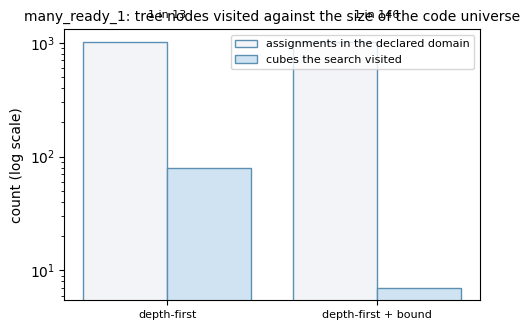

In [15]:
reports = {}
for arm in ("structural_dfs", "structural_bound"):
    rep = ss.search(domain_mr, domain_mr.incumbent, arm, si.Budget(seconds=10.0))
    reports[arm] = rep
    print(f"{arm:17} {rep.status:5}  nodes {rep.nodes:3}  completions {rep.completions:2}  "
          f"pruned {rep.pruned:2}  validations {rep.validations}  J {rep.incumbent_product} -> {rep.best_product}"
          f"  (C={rep.best_cycles}, S={rep.best_scratch}, code {rep.best_index})")

viz.show_search_economy(["depth-first", "depth-first + bound"],
                        [reports["structural_dfs"].nodes, reports["structural_bound"].nodes],
                        [1 << plan_mr.width] * 2,
                        "many_ready_1: tree nodes visited against the size of the code universe")

Both arms return the same answer, a validated compilation with J = 21. Neither
could return a wrong one, because the bound only ever skips subtrees that cannot
win. They differ in effort. Without the bound the search walks the entire tree:
79 nodes and all 40 completions. With it, the search descends to the first J = 21
leaf in **7 nodes**. By then every remaining prefix has a bound of at least 21, and
it stops.

Two further things are worth seeing.

- **The universe is never enumerated.** 1,024 codes, 79 nodes at most. The option
  lists steer the search past every illegal code without constructing it. That is
  the structural encoding doing its job.
- **The verdict is scoped.** `SAT` means a validated strict improvement was found.
  An `UNSAT` here would mean *this declared domain* holds no strict improvement, and
  a budget stop is `UNKNOWN`. Notebook 01 §10 insisted on the same distinction, and
  the search honours it.

---

# 8. On a real program: windows, targets and a stopwatch

A real program is too large to put every decision in one search. The controller
therefore reuses the accepted optimiser's plan (notebook 01 §8) unchanged, so that
only the representation differs.

1. **Targets.** From the incumbent's (C, S), `targets_for` proposes a few
   (cycle ceiling, scratch ceiling) pairs, each with a strictly smaller product.
2. **Windows.** `windows_for` proposes small groups of four operations whose issue
   times, and whose results' lockers, may move. Times may move ±2 cycles. Everything
   outside the window stays fixed.
3. For each (target, window) pair, a **matched domain** is built exactly as the
   accepted joint query would state it, and the structural search runs on it.
4. The first validated improvement becomes the new incumbent, and the plan restarts.
   The controller stops at the time budget or after **32 queries**, the accepted
   optimiser's own cap.

We use `08_vector_reduction`, the one public program on which Phase 2 changed the
answer.

In [16]:
def bootstrap(name):
    prog = machine.load_program(ROOT / f".reference/programs/{name}.json")
    prog_facts = dc.derive(prog)
    compiled, _ = dcomp.compile_with_report(prog, dcomp.DEFAULT_LIMITS, optimise=False)
    return prog, prog_facts, se.issue_cycles_of(prog, compiled["bundles"]), dict(compiled["scratch"])

vr_program, vr_facts, vr_times, vr_addresses = bootstrap("08_vector_reduction")
C, S, J = se.objective(vr_facts, vr_times, vr_addresses)
print(f"08_vector_reduction: {vr_facts.count} operations, {len(vr_facts.value_names)} values")
print(f"bootstrap: C = {C}, S = {S}, J = {J}\n")
print("targets_for  :", dopt.targets_for(vr_facts, C, S))
print("first windows:", dopt.windows_for(vr_facts, vr_times, vr_addresses, scratch_first=True)[:6])

08_vector_reduction: 19 operations, 18 values
bootstrap: C = 12, S = 40, J = 480

targets_for  : [(11, 40), (12, 39), (13, 36), (11, 43)]
first windows: [(9, 12, 15, 16), (13, 14, 17, 18), (0, 1, 2, 3), (2, 3, 4, 5), (4, 5, 6, 7), (6, 7, 8, 9)]


In [17]:
LIMITS = {"query_max_cover": 4096, "search_max_nodes": 50000, "search_max_candidate_validations": 20000}

best_t, best_a, run = rse.structural_optimise(
    vr_program, vr_facts, vr_times, vr_addresses, "structural_bound",
    budget_seconds=1.0, query_seconds=0.1, max_queries=dcomp.DEFAULT_LIMITS.max_queries, limits=LIMITS)

print("result      :", se.objective(vr_facts, best_t, best_a))
print("improvements:", run["improvements"])
print("queries     :", run["attempted_queries"], " statuses:", run["statuses"])
print("stopped     :", run["stopped_because"], f" after {run['seconds'] * 1000:.1f} ms of a 1000 ms budget")

result      : (12, 33, 396)
improvements: [{'window': [9, 12, 15, 16], 'target': [12, 39], 'from': 480, 'to': 396}]
queries     : 32  statuses: {'SAT': 1, 'UNSAT': 7, 'UNKNOWN_SEARCH': 0, 'UNKNOWN_CONSTRUCTION': 0, 'INFEASIBLE': 24, 'FAIL': 0}
stopped     : query_cap  after 4.9 ms of a 1000 ms budget


The first query window, operations {9, 12, 15, 16}, under the target (12, 39)
finds a compilation with **12 cycles and 33 words** instead of 12 and 40. J falls
from 480 to 396. The whole run takes a few milliseconds.

Then the run **stops**. It did not stop because the budget ran out, since 99% of
it is unused. It stopped because it reached the 32-query cap. Look at what the 32
queries were: 24 `INFEASIBLE` and 7 `UNSAT`. An `INFEASIBLE` query is refused
before any search, because an operation *outside* the window already violates the
target. If an untouched operation issues at cycle 11, no rearrangement of the
window can make C ≤ 11.

Now the accepted optimiser, on the same program, at 0.1 s:

accepted optimiser: C, S = 12 40
queries : 22  statuses: {'SAT': 0, 'UNSAT': 3, 'UNKNOWN_CONSTRUCTION': 1, 'UNKNOWN_SEARCH': 1, 'INFEASIBLE': 17}
unknown : {'visited-cube budget exhausted': 1, 'time budget exhausted': 1}
stopped : deadline  after 100.0 ms


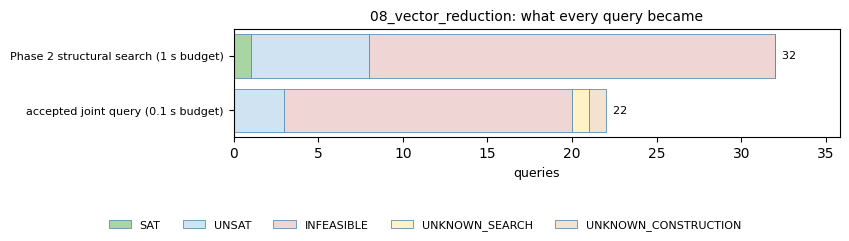

In [18]:
accepted, accepted_report = dcomp.compile_with_report(
    vr_program, dcomp.Limits(optimise_seconds=0.1, query_seconds=0.1), optimise=True)
accepted_opt = accepted_report["optimisation"]
print("accepted optimiser: C, S =", machine.check_compilation(vr_program, accepted),
      dc.footprint(vr_facts, accepted["scratch"]))
print("queries :", accepted_opt["attempted_queries"], " statuses:", accepted_opt["statuses"])
print("unknown :", accepted_opt["unknown_reasons"])
print("stopped :", accepted_opt["stopped_because"], f" after {accepted_opt['seconds'] * 1000:.1f} ms")

order = ["SAT", "UNSAT", "INFEASIBLE", "UNKNOWN_SEARCH", "UNKNOWN_CONSTRUCTION"]
viz.show_stacked_outcomes(
    ["Phase 2 structural search (1 s budget)", "accepted joint query (0.1 s budget)"],
    {name: [run["statuses"].get(name, 0), accepted_opt["statuses"].get(name, 0)] for name in order},
    "08_vector_reduction: what every query became",
    xlabel="queries",
    colours={"SAT": viz.CHOSEN, "UNSAT": viz.FILL, "INFEASIBLE": viz.EXCLUDED,
             "UNKNOWN_SEARCH": "#fff2c6", "UNKNOWN_CONSTRUCTION": "#f3e2cf"})

*(The accepted optimiser runs against the clock, so its exact counts can vary by a
query or two on another machine. The shape does not.)*

This is the core of **H2**. The accepted optimiser asks the *same kind* of question
and uses up its whole 0.1 s. It builds absolute-coordinate covers until one query
exhausts its construction budget and another its search budget, and it accepts
nothing. The structural search asks matched questions over the same domains and
**answers each in well under a millisecond**, because it never constructs the
illegal part of the domain. The gain comes from finishing questions the old
representation could not afford to finish.

## 8.1 The program it still loses on

`05_mixed_broadcast` is the program notebook 01 §11.1 could not explain: the greedy
classical compiler reaches 9 cycles and 17 words against the direct method's 10
and 24. Phase 2 has two arms for it. The matched arm uses the same windows and
targets as above. The **expanded** arm runs one structural search over the whole
program: every operation free over its whole horizon, and every legal locker.

In [19]:
mb_program, mb_facts, mb_times, mb_addresses = bootstrap("05_mixed_broadcast")
print("bootstrap         :", se.objective(mb_facts, mb_times, mb_addresses))
for arm in ("structural_bound", "structural_expanded"):
    t, a, rec = rse.structural_optimise(
        mb_program, mb_facts, mb_times, mb_addresses, arm, budget_seconds=1.0,
        query_seconds=0.1, max_queries=dcomp.DEFAULT_LIMITS.max_queries, limits=LIMITS)
    print(f"{arm:18}: {se.objective(mb_facts, t, a)}   queries {rec['attempted_queries']:2}  "
          f"statuses {({k: v for k, v in rec['statuses'].items() if v})}  {rec['seconds'] * 1000:.0f} ms")

bootstrap         : (10, 24, 240)
structural_bound  : (10, 24, 240)   queries 20  statuses {'UNSAT': 10, 'INFEASIBLE': 10}  3 ms


structural_expanded: (9, 17, 153)   queries  1  statuses {'UNKNOWN_SEARCH': 1}  471 ms


The matched arm spends 20 queries, 10 of them refused as infeasible, and changes
nothing. The expanded arm, free to move everything, finds a far smaller
compilation within its budget. On the machine this notebook was written on, it
reached 9 cycles and 17 words, which is exactly classical's answer. *(This arm searches until the clock stops it, so what it reaches
in one second depends on the machine. In the accepted campaign at 0.1 s it recorded
10 cycles and 17 words.)*

The lesson matters more than the number. **The improvement on this program is not
local.** No window of four operations moving ±2 cycles contains it. The matched
search can answer every question it is asked, but it is not asked this one.
Notebook 03 takes that up directly.

---

# 9. The first error: a sampler that could find almost nothing

Before any search experiment, the plan required a **coverage** check on the real
programs (stage P1). Declare the whole-program domain, with every operation free
over its whole horizon and every legal locker. Then draw 10,000 codes per program in
two ways, and require **at least 100 distinct decoded compilations per program**.

- **Raw bits.** Draw every bit of the code uniformly at random.
- **Option paths.** Walk the decisions and pick uniformly *among the currently legal
  options* at each one, so no choice is ever illegal when it is made.

Every completed decode is validated. The point is to see the codec work on real
programs at scale, not only on fixtures. Here are 1,000 draws of each kind on two
public programs, drawn by the campaign's own seeded samplers.

01_scalar_pipeline: code 0 -> COMPLETE, J = 84 (bootstrap J = 84)


02_scalar_dual_chain: code 0 -> COMPLETE, J = 24 (bootstrap J = 24)


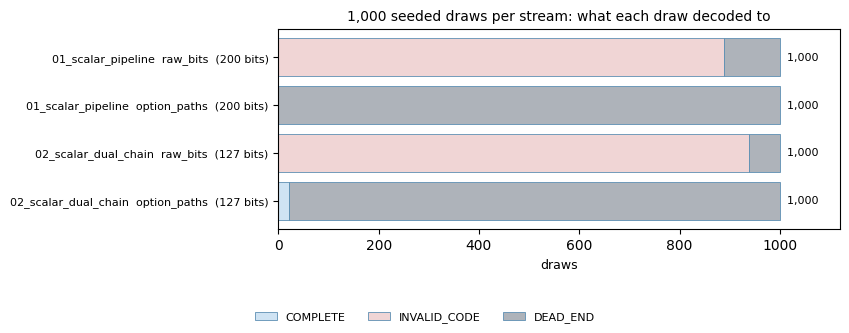

In [20]:
sampling = {}
depths = {}
for name in ("01_scalar_pipeline", "02_scalar_dual_chain"):
    prog, prog_facts, times, addresses = bootstrap(name)
    whole = rse.whole_program_record(name, "public", prog, prog_facts,
                                     dc.compilation(prog_facts, times, addresses))
    whole_domain = se.Domain.from_record(whole)
    width = se.layout(whole_domain, "structural_rank").width
    for stream, seed in (("raw_bits", 20260922), ("option_paths", 20260923)):
        results = [se.decode(whole_domain, z, "structural_rank")
                   for z in rse.stream_indices(whole_domain, "structural_rank", stream, seed, 1000)]
        sampling[f"{name}  {stream}  ({width} bits)"] = collections.Counter(r.status for r in results)
        if stream == "option_paths":
            depths[name] = collections.Counter(len(r.decisions) for r in results if r.status == "DEAD_END")
    origin = se.decode(whole_domain, 0, "structural_rank")
    print(f"{name}: code 0 -> {origin.status}, J = {origin.product} "
          f"(bootstrap J = {se.objective(prog_facts, times, addresses)[2]})")

viz.show_stacked_outcomes(
    list(sampling), {status: [c.get(status, 0) for c in sampling.values()]
                     for status in ("COMPLETE", "INVALID_CODE", "DEAD_END")},
    "1,000 seeded draws per stream: what each draw decoded to", xlabel="draws")

The raw-bit draws are almost all `INVALID_CODE`. A 5-bit time field can name 32
ranks when perhaps 23 cycles are legal, a 2-bit field can name 4 ranks when 1 is
legal, and a code has dozens of such fields. Getting every one of them right by
chance almost never happens.

The option-path draws never make an illegal choice, and still they **die**: every
draw on `01_scalar_pipeline`, and nearly every draw on `02_scalar_dual_chain`. Here
is where they die, measured by how many decisions they got through before one had
no legal option.

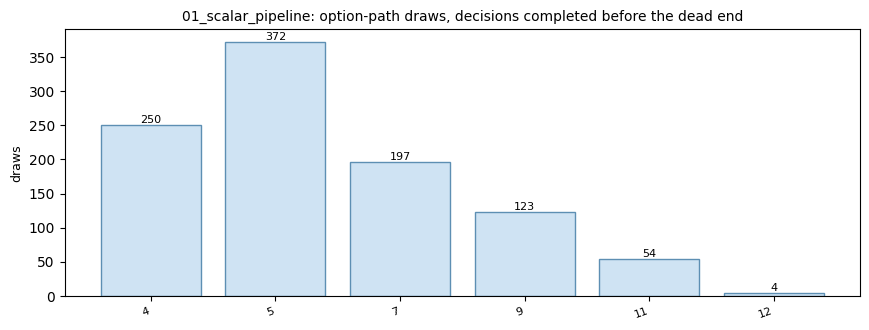

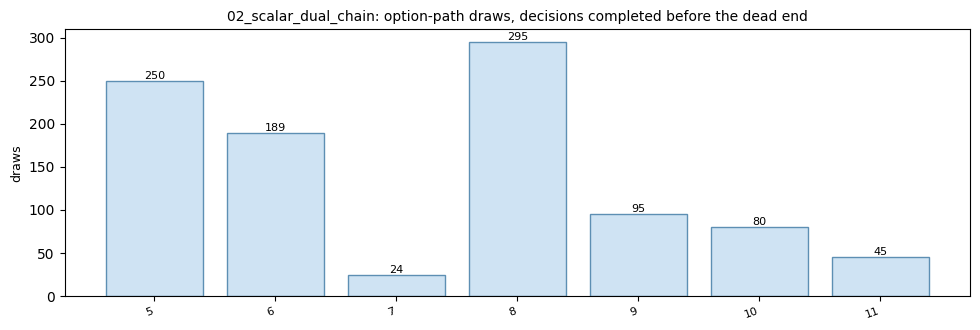

In [21]:
for name, counter in depths.items():
    depth_values = sorted(counter)
    viz.show_bars([str(d) for d in depth_values], [counter[d] for d in depth_values],
                  f"{name}: option-path draws, decisions completed before the dead end",
                  "draws", fmt="{:.0f}")

The accepted diagnosis replayed the first failed draw of each program and named
the exact constraint. On `01_scalar_pipeline` the random walk issued operation 6
at cycle 22, uniformly and legally. Operation 8 needs operation 6's result one
cycle later, at cycle 23. The declared horizon ends at cycle 22. **No cycle is left
for operation 8**, and there was no way to know that when operation 6 was placed.

retained index: 515832456427 -> DEAD_END -- ('time', 8): no legal option remains
choices made before it: [(0, 11), (1, 7), (2, 9), (3, 19), (4, 21), (5, 13), (6, 22), (7, 15)]
replayed live : DEAD_END -- ('time', 8): no legal option remains
horizon       : cycles 0 .. 22


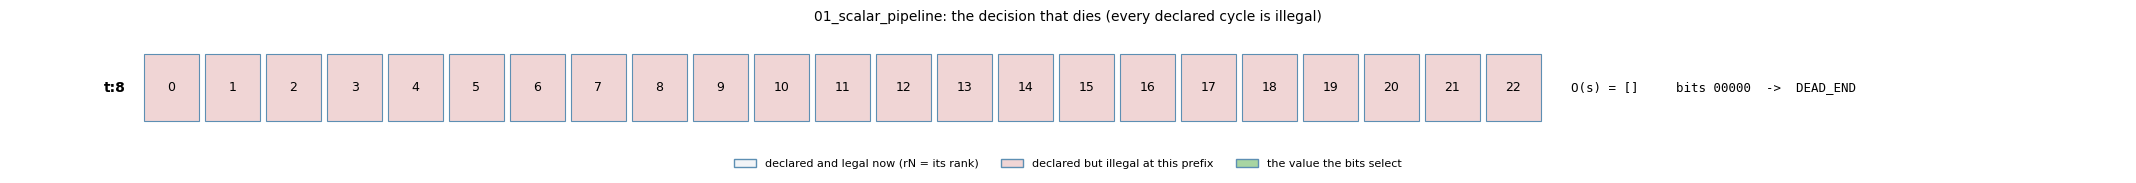

In [22]:
diagnosis = json.loads((EVIDENCE / "recovery_diagnosis_20260923/DIAGNOSIS.json").read_text())
failure = diagnosis["public_programs"]["01_scalar_pipeline.json"]["first_option_path_failure"]
print("retained index:", failure["index"], "->", failure["status"], "--", failure["reason"])
print("choices made before it:", [(d["key"], d["chosen"]) for d in failure["decisions"] if d["chosen"] is not None])

prog, prog_facts, times, addresses = bootstrap("01_scalar_pipeline")
whole_domain = se.Domain.from_record(rse.whole_program_record(
    "01", "public", prog, prog_facts, dc.compilation(prog_facts, times, addresses)))
replayed, replay_rows = replay_steps(whole_domain, int(failure["index"]))
print("replayed live :", replayed.status, "--", replayed.reason)
print("horizon       : cycles 0 ..", prog_facts.horizon - 1)
viz.show_decode_steps(replay_rows[-1:], "01_scalar_pipeline: the decision that dies (every declared cycle is illegal)")

Across the full campaign the counts were 160,000 draws over 16 streams. Of those,
**819** decoded to complete compilations, and all 819 were validated on every case
with **zero discrepancies**. Four public programs fell short of the 100-compilation
minimum, one of them with zero. The stage was therefore declared **INCONCLUSIVE**,
and every dependent experiment was blocked until a reviewed amendment.

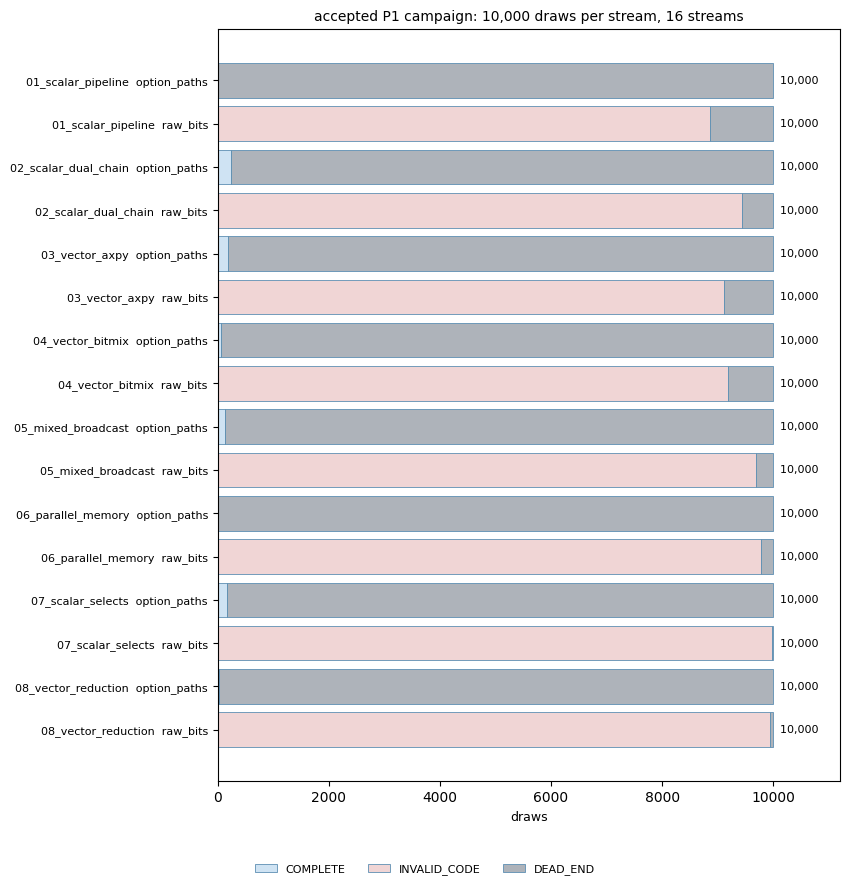

original P1: {'sampling_attempts': 160000, 'streams': 16, 'completions': 819, 'case_checks': 1356, 'case_failures': 0, 'discrepancies': 0, 'coverage_minimum': 100, 'coverage_met': False}


In [23]:
streams = diagnosis["streams"]
labels = [f"{s['program'][:-5]}  {s['stream']}" for s in streams]
viz.show_stacked_outcomes(
    labels, {status: [s["outcomes"].get(status, 0) for s in streams]
             for status in ("COMPLETE", "INVALID_CODE", "DEAD_END")},
    "accepted P1 campaign: 10,000 draws per stream, 16 streams", xlabel="draws")
print("original P1:", diagnosis["original_p1"])

This was the first real error of Phase 2, and it is worth being precise about
what kind of error it was.

- It was **not** a codec defect. Every completed decode was legal, and the
  bootstrap of every program round-tripped through all four codecs.
- It **was** a design error in the *check*. The two samplers do not sample
  compilations uniformly, and the whole-program domain is full of legal prefixes
  that cannot be completed. The coverage threshold measured the sampler's luck, not
  the codec's reach.
- The fix, reviewed and recorded as the *recovery amendment*, kept the original
  result as INCONCLUSIVE, added a coverage probe in physical coordinates, and let the
  independent stages proceed. It did not quietly lower the threshold.

Keep the mechanism in mind, because it returns in notebook 03. **Legal next choices
do not guarantee a completion.** The plan says so in its list of corrected claims,
and here it is, measured.

---

# 10. Is the good set compact? (H3)

This is where the index-set idea of notebook 01 comes back. If good compilations
share structure in these coordinates, then the set of good codes should be
describable by **a few cubes**, meaning a few fixed bits and many free ones. That
is a short description. Random sets of the same size should need many cubes.

Start with `chain_0`. Its good set, the codes with J ≤ 16, is {0, 8}.

elite codes : [0, 8]
exact cover : COMPLETE ['x0..x6:000*000']
serialised  : 4 bytes  (the same two codes as minterms: 6 bytes)


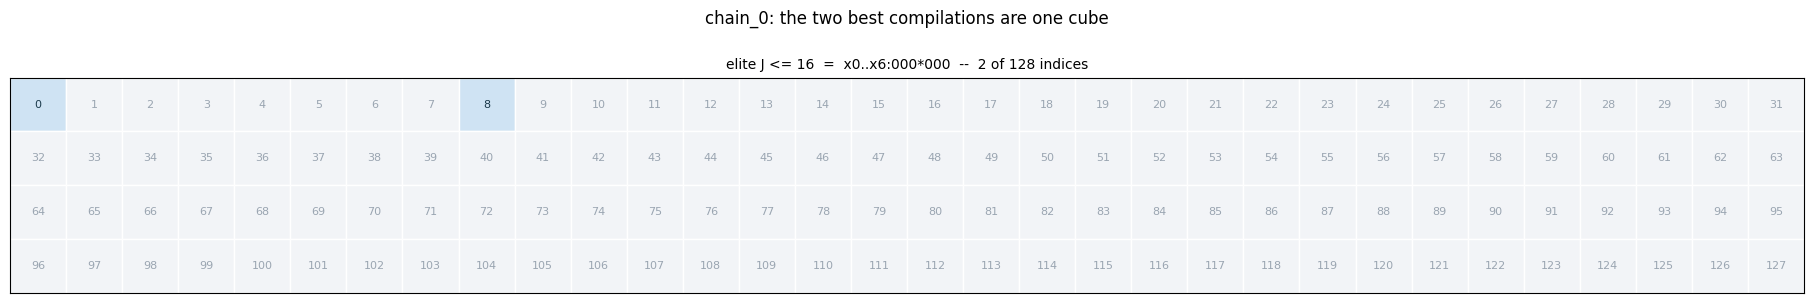

In [24]:
elite = [z for z, status in enumerate(chain_structural)
         if status == "COMPLETE" and se.decode(domain, z, "structural_rank").product <= 16]
cover = sm.exact_cover(elite, 7, 65536, 10)
print("elite codes :", elite)
print("exact cover :", cover.status, [cube.label() for cube in cover.cubes])
print("serialised  :", len(sm.serialise_cover(cover.cubes, 7)), "bytes",
      " (the same two codes as minterms:",
      len(sm.serialise_cover([si.Cube(7, z, 0) for z in elite], 7)), "bytes)")
viz.show_universe([("elite J <= 16  =  " + cover.cubes[0].label(), cover.cubes)], 7,
                  "chain_0: the two best compilations are one cube", per_row=32)

One cube, `x0..x6:000*000`. Every field is at rank 0 (the incumbent's choice)
except bit 3, the low bit of `a`'s locker, which is free. **In words: keep
everything as the incumbent has it, and put `a` in either of its first two legal
lockers.** That is a genuine description of why these two are the best, and it is
four bytes long.

H3 asks whether that is a *special* property of good sets or just what any two
codes would give. The test uses the same cover procedure on 100 random sets of legal
codes of the **same size**, and compares the serialised lengths. On `chain_0` the
answer is "nothing special": random pairs also often form one cube. The frozen
result for every fixture:

In [25]:
p3 = json.loads((EVIDENCE / "recovery_campaign_20260923_r3/p3/summary.json").read_text())
print(f"{'fixture':22} {'legal':>5} {'elite':>5}   {'structural: elite bytes / random median':>40}   {'absolute: elite / random':>26}")
for fx in p3["fixtures"]:
    if not fx["informative"]:
        print(f"{fx['id']:22} {fx['feasible']:>5}     -   uninformative: {fx['uninformative_reason']}")
        continue
    s, a = fx["codecs"]["structural_rank"], fx["codecs"]["absolute"]
    print(f"{fx['id']:22} {fx['feasible']:>5} {fx['elite_count']:>5}   "
          f"{s['elite_bytes']:>15} / {s['control_median_bytes']:<6} {'meets 20%' if s['meets_triage'] else '':>12}"
          f"   {a['elite_bytes']:>12} / {a['control_median_bytes']:<6}")
print("\ntriage:", p3["triage"]["status"], "--", p3["qualifying_count"], "of", p3["informative_count"],
      "informative fixtures meet the margin, spanning", p3["qualifying_families"])

fixture                legal elite    structural: elite bytes / random median     absolute: elite / random
chain_0                    6     2                 4 / 4.0                              8 / 8.0   
chain_1                    6     2                 6 / 10.0      meets 20%              8 / 14.0  
many_ready_0               2     -   uninformative: all objectives are equal
many_ready_1              40    22                54 / 54.0                            74 / 86.0  
memory_bottleneck_0       12     4                 4 / 8.0       meets 20%             20 / 20.0  
memory_bottleneck_1       18     8                 6 / 22.0      meets 20%             14 / 32.0  
sparse_0                  12     4                 4 / 8.0       meets 20%              8 / 20.0  
sparse_1                   9     4                 6 / 14.0      meets 20%              8 / 20.0  
mixed_lifetimes_0          6     3                 6 / 6.0                             14 / 14.0  
mixed_lifetimes_1       

Read `memory_bottleneck_0`. Its four best compilations need 4 bytes in structural
coordinates, where the median random set of four legal codes needs 8, and the same
four written in absolute coordinates need 20. The good set is *more regular than
chance* in these coordinates. In 7 of the 11 informative fixtures, across three
families, the good set is at least 20% shorter than the random median. That passed
the preregistered triage threshold, and **H3 is supported as a triage signal**.

It is a triage signal and nothing more. The fixtures are tiny, the threshold is a
research gate rather than a statistical test, and "shorter than random" on a few
dozen codes says nothing yet about a real program. What it licensed was the
experiment in the next section.

---

# 11. Can the cover discover anything new? (H4)

Suppose the elite cover really captures *why* those compilations are good. Can it
be used to **propose unseen good compilations**?

Not as it stands. An exact cover of the observed elites denotes *exactly* those
elites and nothing else. Sampling from it can only return what was already seen.
Generalising needs a rule that goes beyond the data, and the plan froze the
simplest one: **free one more coordinate of each cube**, and propose every new code
the enlarged cubes contain.

Watch what that rule actually does. Take `memory_bottleneck_1`, pretend we have
seen only two of its best compilations, and compare the enlarged cover's
proposals with a rule that uses no cover at all: *flip one bit of a seen elite*.

all elite codes (hidden)   : [0, 1, 32, 33, 128, 129, 160, 161]
seen                       : [0, 1]   cover: ['x0..x8:*00000000']
enlarged-cover proposals   : [2, 3, 4, 5, 8, 9, 16, 17, 32, 33, 64, 65, 128, 129, 256, 257]
one-bit-flip proposals     : [2, 3, 4, 5, 8, 9, 16, 17, 32, 33, 64, 65, 128, 129, 256, 257]
identical, in the same order: True
proposals that are unseen elites: [32, 33, 128, 129]  (4 of 16 proposals)


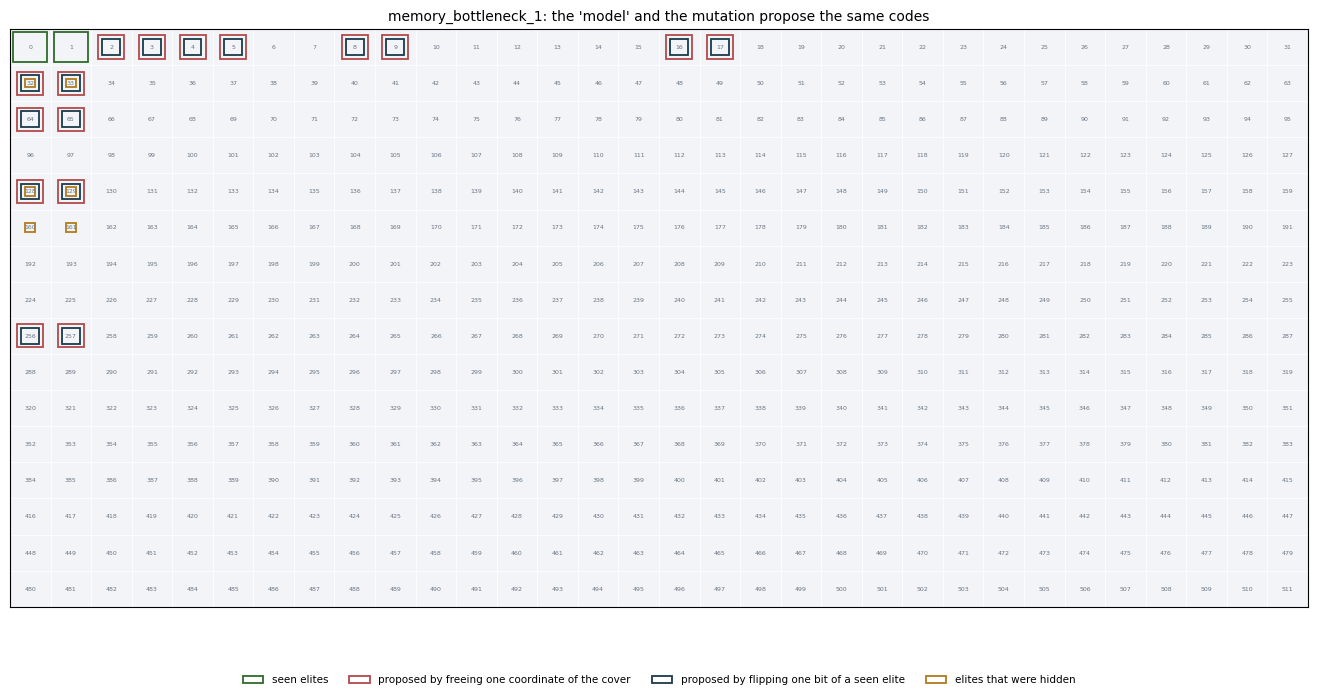

In [26]:
record_mb = FIXTURES["memory_bottleneck_1"]
domain_mb = se.Domain.from_record(record_mb)
bits_mb = se.layout(domain_mb, "structural_rank").width
decoded_mb = {z: se.decode(domain_mb, z, "structural_rank") for z in range(1 << bits_mb)}
best_mb = min(r.product for r in decoded_mb.values() if r.status == "COMPLETE")
all_elite = sorted(z for z, r in decoded_mb.items() if r.status == "COMPLETE" and r.product == best_mb)
seen = all_elite[:2]

seen_cover = sm.exact_cover(seen, bits_mb, 65536, 10).cubes
expanded = [z for z, duplicate in sm.proposals("model_expand", bits_mb, seen, seen_cover, set(seen), None)
            if not duplicate]
one_bit = [z for z, duplicate in sm.proposals("one_bit", bits_mb, seen, seen_cover, set(seen), None)
           if not duplicate]

print("all elite codes (hidden)   :", all_elite)
print("seen                       :", seen, "  cover:", [c.label() for c in seen_cover])
print("enlarged-cover proposals   :", expanded)
print("one-bit-flip proposals     :", one_bit)
print("identical, in the same order:", expanded == one_bit)
hits = [z for z in expanded if z in all_elite]
print(f"proposals that are unseen elites: {hits}  ({len(hits)} of {len(expanded)} proposals)")

viz.show_index_scores(
    bits_mb, {}, "memory_bottleneck_1: the 'model' and the mutation propose the same codes",
    outlined={"seen elites": seen,
              "proposed by freeing one coordinate of the cover": expanded,
              "proposed by flipping one bit of a seen elite": one_bit,
              "elites that were hidden": sorted(set(all_elite) - set(seen))})

Every proposed code carries two nested outlines, one for each rule, and no code
carries only one. A quarter of the proposals are hidden elites (32, 33, 128, 129),
so the rule is not useless. But the plain bit flip finds exactly the same ones.

The two lists are **identical, element for element**. That is not a coincidence of
this example. It is a theorem, found by Codex while reviewing this phase:

> For any exact cover Q of a set E, freeing one fixed coordinate in each cube and
> removing E gives exactly the one-bit neighbours of E that are not in E.
> *Forward:* a new point of an enlarged cube differs from a point of the original
> cube only in the freed coordinate. *Backward:* if x ∉ E differs from some e ∈ E in
> coordinate j, then j is fixed in the cube containing e (otherwise x would already
> be in E), and freeing j reaches x.

So the frozen "model" was a mutation operator with extra bookkeeping. It could
never be better than flipping bits, and the experiment could not have shown a
learning effect. The accepted H4 result was **inconclusive**: one informative
fixture instead of the three required, and zero advantage against either control.
The theorem explains *why* it could not have come out otherwise. It was checked on
every elite set up to width 3 (278 sets) and on 500 larger random ones, and it is
the first of the findings that shaped notebook 03.

---

# 12. What Phase 2 achieved, against every baseline

Now the measured outcome. The confirmatory test was fixed in advance. It uses 100
**held-out generated programs** (20 from each of five families, never seen during
development) and a **0.1 s** optimisation budget. It compares `structural_bound`
against the accepted direct optimiser given the same budget, using the paired
endpoint mean log(J_control / J_candidate): positive means Phase 2 produced the
lower J. Everything is read from the frozen comparison.

primary H2: structural_bound vs accepted_budgeted, held-out, 0.1 s
   estimate +0.0439  95% [+0.0251, +0.0660]   wins/ties/losses 26/74/0 over 100 programs


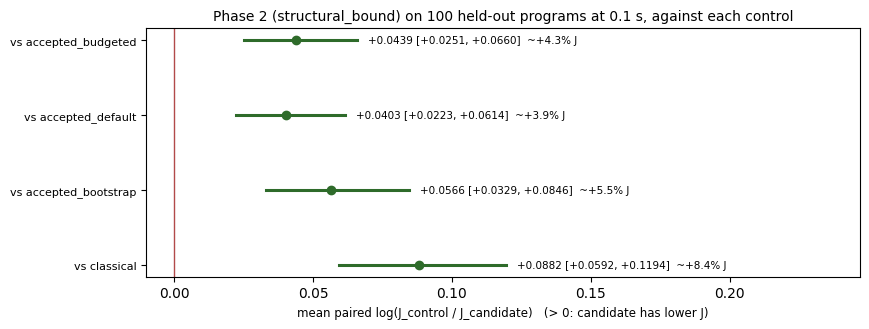

control                   W/T/L    mean C cand/ctrl  mean S cand/ctrl   compile time ratio
accepted_budgeted     26/74/0       13.97 / 13.96     37.71 / 38.66            0.073x
accepted_default      25/75/0       13.97 / 13.96     37.71 / 38.63            0.042x
accepted_bootstrap    31/69/0       13.97 / 13.98     37.71 / 38.77            4.009x
classical             53/35/12      13.97 / 13.70     37.71 / 41.93            7.286x


In [27]:
comparison = json.loads((EVIDENCE / "recovery_campaign_20260923_r3/COMPARISON.json").read_text())
primary = comparison["primary_h2"]["analysis"]
low, high = primary["interval"]["intervals"]["0.025-0.975"]
print(f"primary H2: {primary['candidate_arm']} vs {primary['baseline_arm']}, held-out, {primary['budget_seconds']} s")
print(f"   estimate {primary['interval']['point_estimate']:+.4f}  95% [{low:+.4f}, {high:+.4f}]"
      f"   wins/ties/losses {primary['wins']}/{primary['ties']}/{primary['losses']} over {primary['interval']['programs']} programs")

rows, table = [], []
for entry in comparison["entries"]:
    if entry["corpus"] != "heldout" or entry["budget_seconds"] != 0.1:
        continue
    q = entry["quality_log_control_over_candidate"]
    rows.append((f"vs {entry['control']}", q["point_estimate"], *q["intervals"]["0.025-0.975"]))
    table.append(entry)
viz.show_effects(rows, "Phase 2 (structural_bound) on 100 held-out programs at 0.1 s, against each control")

print(f"{'control':20} {'W/T/L':>10}   {'mean C cand/ctrl':>17} {'mean S cand/ctrl':>17}   {'compile time ratio':>18}")
for entry in table:
    m = entry["mean_per_program_C_S_J"]
    cand, ctrl = m[entry["candidate"]], m[entry["control"]]
    print(f"{entry['control']:20} {entry['wins']:>3}/{entry['ties']}/{entry['losses']:<3}   "
          f"{cand['cycles']:>7.2f} / {ctrl['cycles']:<7.2f} {cand['scratch']:>7.2f} / {ctrl['scratch']:<7.2f}   "
          f"{entry['compile_candidate_over_control_ratio']:>12.3f}x")

Four readings, each with its reference.

1. **Against the accepted optimiser at the same budget**, J is about 4.3% lower
   (estimate 0.0439, 95% interval [0.0251, 0.0660]) with 26 wins, 74 ties and **no
   losses**. The interval excludes zero, so **H2 is supported** on this population.
   Phase 2 also takes about 0.07 times the accepted optimiser's compile time. That
   is not because it is fast. The accepted optimiser uses its whole budget, and
   Phase 2 stops early.
2. **The gain is almost entirely memory.** Mean cycles are unchanged (13.97 against
   13.96) and mean scratch falls from 38.66 to 37.71 words. The windowed search
   repacks lockers and almost never shortens a schedule.
3. **Against the classical greedy compiler** the descriptive reduction is about
   8.4%, with 53 wins, 35 ties and 12 losses. The two trade differently: classical
   produces *shorter* schedules (13.70 cycles against 13.97) but much larger
   footprints (41.93 words against 37.71). It is not uniform, and it costs
   about 7.3 times classical's compile time.
4. **Three-quarters of the programs are ties.** For most programs the search finds
   nothing to improve within its windows.

And the eight public programs, scored exactly with the official formula:

In [28]:
recount = json.loads((EVIDENCE / "lead_release_review_20260924/PUBLIC_SCORE_RECOUNT.json").read_text())
for arm, entry in recount["arms"].items():
    print(f"{arm:18} public score {entry['scores'][0]:.6f}   (identical in all {len(entry['scores'])} repetitions)")
print(f"\ngain vs original direct: {recount['relative_gain_vs_original'] * 100:.2f}%   "
      f"gain vs classical: {recount['relative_gain_vs_classical'] * 100:.2f}%")

public_rows = [json.loads(line) for line in
               (EVIDENCE / "recovery_campaign_20260923_r3/p5/public_rows.jsonl").read_text().splitlines()]
per_program = collections.defaultdict(dict)
for row in public_rows:
    if row["repetition"] == 0 and row["budget_seconds"] in (0.1, None):
        per_program[row["program_name"]][row["arm"]] = (row["cycles"], row["scratch"])
print(f"\n{'program':18} {'classical':>10} {'accepted':>10} {'Phase 2':>10}")
for name, arms in sorted(per_program.items()):
    fmt = lambda cs: f"{cs[0]}x{cs[1]}"
    mark = "   <- changed" if arms["structural_bound"] != arms["accepted_budgeted"] else ""
    print(f"{name:18} {fmt(arms['classical']):>10} {fmt(arms['accepted_budgeted']):>10} "
          f"{fmt(arms['structural_bound']):>10}{mark}")

structural_bound   public score 2.032760   (identical in all 15 repetitions)
accepted_default   public score 2.008466   (identical in all 15 repetitions)
accepted_budgeted  public score 2.008466   (identical in all 15 repetitions)
classical          public score 1.901379   (identical in all 15 repetitions)

gain vs original direct: 1.21%   gain vs classical: 6.91%

program             classical   accepted    Phase 2
mixed_broadcast          9x17      10x24      10x24
parallel_memory         14x56      13x40      13x40
scalar_dual_chain         9x5        8x3        8x3
scalar_pipeline          14x6       14x6       14x6
scalar_selects            9x6        9x6        9x6
vector_axpy             10x32      10x24      10x24
vector_bitmix           10x40      10x40      10x40
vector_reduction        12x40      12x40      12x33   <- changed


On the fixed public suite Phase 2 scores **2.0328** against the original direct
compiler's 2.0085 (+1.21%) and classical's 1.9014 (+6.91%). The whole of that gain
comes from **one program**, `vector_reduction`, whose footprint fell from 40 to 33
words exactly as in §8. The other seven are unchanged. This is exact arithmetic on
eight fixed programs. It says nothing about the private grader.

---

# 13. Why it did not get better

Phase 2 works, and it is correct, and it helps a quarter of generated programs by
a few percent. Why not more? Every reason below is visible in something this
notebook has already run.

## 13.1 The question list runs out, not the clock

§8 used 5 ms of a 1,000 ms budget and then stopped at the 32-query cap. The accepted
optimiser needed that cap because each of its queries was expensive. Phase 2's
queries are cheap, and the cap was left unchanged to keep the comparison matched.
Most of the budget is simply never spent.

## 13.2 The target rectangles ask the wrong questions

Each query asks for C ≤ Ct **and** S ≤ St, which is a rectangle in the (C, S) plane.
An improvement only needs C × S < J₀, which is the whole region under a hyperbola. The
rectangles do not cover that region. Codex found the smallest example by calling
the real `targets_for`: incumbent (10, 10), J = 100.

incumbent             : [10, 10]
targets_for proposes  : [[9, 10], [10, 9], [11, 9], [9, 11]]
a strict improvement  : [12, 8]  J = 96
inside any rectangle? : False


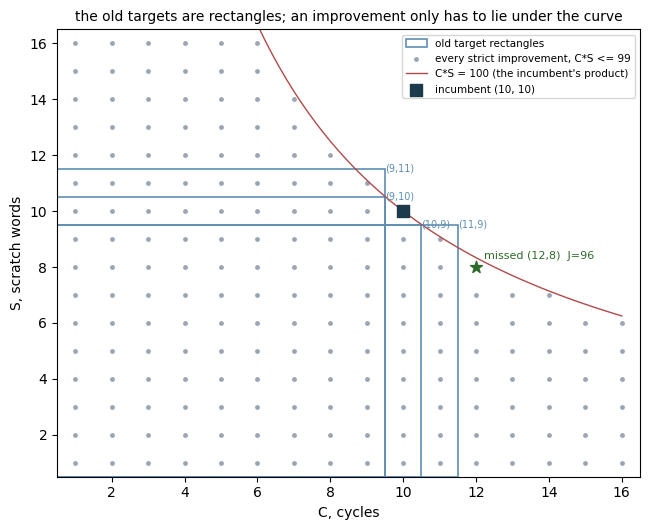

In [29]:
counterexample = json.loads((EVIDENCE / "scientific_design_20260924/PRODUCT_TARGET_COUNTEREXAMPLE.json").read_text())
print("incumbent             :", counterexample["incumbent"])
print("targets_for proposes  :", counterexample["old_targets"])
print("a strict improvement  :", counterexample["strict_improvement_pair"], " J =", counterexample["candidate_product"])
print("inside any rectangle? :", counterexample["old_rectangle_union_contains_pair"])
viz.show_objective_plane(tuple(counterexample["incumbent"]),
                         "the old targets are rectangles; an improvement only has to lie under the curve",
                         targets=[tuple(t) for t in counterexample["old_targets"]],
                         points=[("missed", tuple(counterexample["strict_improvement_pair"]))],
                         c_range=(1, 16), s_range=(1, 16))

Every grey dot under the red curve is a strict improvement. The blue rectangles
are what the controller can ask for. The point (12, 8) has J = 96 < 100, but it
spends *more* cycles to save memory, and no rectangle reaches it. The scope is
exact: this is geometry. It shows the question list has holes, not that a
particular program has an improvement in one.

The rectangles also produce most of the refusals. In §8, 24 of the 32 queries were
`INFEASIBLE`: a fixed operation outside the window already broke the rectangle's
cycle or memory ceiling, so the query was refused before any search.

## 13.3 The windows are local

Four operations, ±2 cycles. `mixed_broadcast` (§8.1) needed a move no such window
contains, and only the whole-program search found it. Held-out cycle counts barely
moved at all (13.97 against 13.96), because shortening a schedule usually means
moving many operations together.

## 13.4 The 'model' was a mutation

§11 proved it. Freeing one coordinate of an exact cover proposes exactly the one-bit
neighbours. There was nothing learned for H4 to measure.

## 13.5 The coordinates do not create compilations

§5 showed that the static and structural codecs contain exactly the same legal
compilations. The encoding changes the **cost** of reaching an improvement, not
**which** improvements exist in a declared domain. Given the same windows and
targets, the best Phase 2 can do is answer every matched question. After §8 it
does that almost for free. The remaining gains have to come from **asking better
questions**: more of them, better-shaped, larger, and in a better order.

That sentence is the brief of notebook 03.

---

# 14. What to take away, and what to try

**The idea.** Write each decision as a rank among the options still legal. The
coordinates then carry the constraints: an illegal choice cannot be named, a bad
choice fails at the field that made it, and code 0 is the incumbent.

**What it buys.** Correctness that can be checked exhaustively (H1), and matched
queries answered in well under a millisecond where the absolute query ran out of
budget. That gives about 4.3% lower J on held-out programs at equal budget, with no
losses (H2).

**What it does not buy.** New compilations. The legal set is unchanged, most of
the budget goes unspent, the question list is rectangular and local, and the
proposed model was provably a mutation operator.

**Where the errors were.** The coverage check (§9) measured the samplers, not the
codec, and was honestly left INCONCLUSIVE. The model experiment (§11) could not
have succeeded by construction. Both were caught by review and neither was
papered over.

## Exercises

1. In §4, decode code 16 and code 24 by hand before running `replay_steps`. Which
   locker does `a` get, and what are C, S and J?
2. In §5, count the dead ends of `chain_1` under both codecs. Find the one decision
   whose early choice kills every completion.
3. In §7, change the budget of the `structural_bound` arm to
   `si.Budget(seconds=10.0, max_visited=4)`. What status does the search report now,
   and why is it not `UNSAT`?
4. In §8, raise `max_queries` to 200 and rerun. Does `vector_reduction` improve
   further? What do the new queries turn into?
5. In §11, set `seen = all_elite[:4]` and check that the equality still holds. Then
   count how many proposals decode to COMPLETE at all.

---

## References

These are the sources cited by the Phase 2 plan (§12) for context. None of them
proves anything about this compiler, and none is claimed as precedent for the
specific encoding.

- J. F. Gonçalves and M. G. C. Resende, *A biased random-key genetic algorithm for
  job-shop scheduling*, technical report, 2011,
  [optimization-online.org/2011/04/2995](https://optimization-online.org/2011/04/2995/).
  Schedules decoded from chromosomes. **Validity by decoding is established
  practice**, so it is context here and not a novelty claim.
- M. Pelikan, D. E. Goldberg and E. Cantú-Paz, *BOA: the Bayesian optimization
  algorithm*, GECCO 1999, and M. Pelikan, *Hierarchical Bayesian Optimization
  Algorithm*, Springer, 2005,
  [doi:10.1007/b10910](https://link.springer.com/book/10.1007/b10910). Models are
  learned from good solutions and sampled. This is the comparison class for H4.
- S. Hack, D. Grund and G. Goos, *Register allocation for programs in SSA form*,
  CC 2006, and the Saarland SSA register-allocation project,
  [compilers.cs.uni-saarland.de/projects/ssara](https://www.compilers.cs.uni-saarland.de/projects/ssara/).
  This qualifies blanket NP-hardness claims: with the schedule fixed, scalar live
  intervals are an interval-colouring problem.

The literature behind the improvements is in notebook 03.